In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

import pickle

In [16]:
df = pd.read_csv(r"C:\Users\ashok\Downloads\zepto_medipally_final_dataset.csv")

In [17]:
df

,order_id,partner_id,store_name,store_latitude,store_longitude,delivery_area,delivery_latitude,delivery_longitude,distance_km,grocery_category,...,orders_delivered,avg_distance_per_order_km,total_distance_km,base_earning_per_order,surge_earning,peak_bonus,weekend_bonus,festival_bonus,fuel_deduction,total_earnings
0,E24,HYDMEDSTORE103DEL02,Zepto SS Store — Medipally,17.4399,78.5667,Neredmet,17.455115,78.579055,2.14,Bakery,...,26,1.8,46.8,15,0.00,4.77,32,0,84.24,342.53
1,DD7C,HYDMEDSTORE180DEL02,Zepto SS Store — Medipally,17.4399,78.5667,Ghatkesar,17.432850,78.554401,1.52,Frozen Foods,...,19,1.7,32.3,15,213.75,29.68,0,0,38.76,489.67
2,4040,HYDMEDSTORE093DEL02,Zepto SS Store — Medipally,17.4399,78.5667,Kushaiguda,17.401527,78.507678,7.58,Personal Care,...,26,8.0,208.0,15,23.40,7.69,0,0,374.40,100.00
3,ED68,HYDMEDSTORE015DEL03,Zepto SS Store — Medipally,17.4399,78.5667,ECIL,17.431002,78.597538,3.42,Frozen Foods,...,13,3.9,50.7,15,117.00,5.87,0,0,91.26,226.61
4,F4AF,HYDMEDSTORE107DEL03,Zepto SS Store — Medipally,17.4399,78.5667,Kushaiguda,17.400352,78.621228,7.27,Snacks & Beverages,...,15,7.4,111.0,15,0.00,4.60,0,0,133.20,100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CCF7,HYDMEDSTORE041DEL02,Zepto SS Store — Medipally,17.4399,78.5667,Kushaiguda,17.383099,78.553280,6.47,Snacks & Beverages,...,17,7.4,125.8,15,33.15,19.26,44,0,150.96,200.45
99996,C306,HYDMEDSTORE155DEL03,Zepto SS Store — Medipally,17.4399,78.5667,Nagole,17.397812,78.509083,7.70,Frozen Foods,...,18,8.0,144.0,15,0.00,27.72,0,0,259.20,100.00
99997,71CD,HYDMEDSTORE098DEL02,Zepto SS Store — Medipally,17.4399,78.5667,Nagole,17.461704,78.594662,3.83,Bakery,...,17,4.1,69.7,15,132.60,48.55,0,73,83.64,425.51
99998,4A97,HYDMEDSTORE057DEL01,Zepto SS Store — Medipally,17.4399,78.5667,Habsiguda,17.454646,78.519139,5.30,Household Essentials,...,18,5.0,90.0,15,299.70,18.78,0,0,108.00,480.48


In [18]:
df.head()

,order_id,partner_id,store_name,store_latitude,store_longitude,delivery_area,delivery_latitude,delivery_longitude,distance_km,grocery_category,...,orders_delivered,avg_distance_per_order_km,total_distance_km,base_earning_per_order,surge_earning,peak_bonus,weekend_bonus,festival_bonus,fuel_deduction,total_earnings
0,E24,HYDMEDSTORE103DEL02,Zepto SS Store — Medipally,17.4399,78.5667,Neredmet,17.455115,78.579055,2.14,Bakery,...,26,1.8,46.8,15,0.00,4.77,32,0,84.24,342.53
1,DD7C,HYDMEDSTORE180DEL02,Zepto SS Store — Medipally,17.4399,78.5667,Ghatkesar,17.432850,78.554401,1.52,Frozen Foods,...,19,1.7,32.3,15,213.75,29.68,0,0,38.76,489.67
2,4040,HYDMEDSTORE093DEL02,Zepto SS Store — Medipally,17.4399,78.5667,Kushaiguda,17.401527,78.507678,7.58,Personal Care,...,26,8.0,208.0,15,23.40,7.69,0,0,374.40,100.00
3,ED68,HYDMEDSTORE015DEL03,Zepto SS Store — Medipally,17.4399,78.5667,ECIL,17.431002,78.597538,3.42,Frozen Foods,...,13,3.9,50.7,15,117.00,5.87,0,0,91.26,226.61
4,F4AF,HYDMEDSTORE107DEL03,Zepto SS Store — Medipally,17.4399,78.5667,Kushaiguda,17.400352,78.621228,7.27,Snacks & Beverages,...,15,7.4,111.0,15,0.00,4.60,0,0,133.20,100.00


In [19]:
df.shape

(100000, 30)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   order_id                   100000 non-null  object 
 1   partner_id                 100000 non-null  object 
 2   store_name                 100000 non-null  object 
 3   store_latitude             100000 non-null  float64
 4   store_longitude            100000 non-null  float64
 5   delivery_area              100000 non-null  object 
 6   delivery_latitude          100000 non-null  float64
 7   delivery_longitude         100000 non-null  float64
 8   distance_km                100000 non-null  float64
 9   grocery_category           100000 non-null  object 
 10  product_item               100000 non-null  object 
 11  num_items_in_order         100000 non-null  int64  
 12  vehicle_type               100000 non-null  object 
 13  day_of_week                100

### Missing values

In [22]:
df.isnull().sum()

order_id                     0
partner_id                   0
store_name                   0
store_latitude               0
store_longitude              0
delivery_area                0
delivery_latitude            0
delivery_longitude           0
distance_km                  0
grocery_category             0
product_item                 0
num_items_in_order           0
vehicle_type                 0
day_of_week                  0
is_weekend                   0
is_festival_day              0
login_hours                  0
peak_hours_worked            0
weather                      0
surge_multiplier             0
orders_delivered             0
avg_distance_per_order_km    0
total_distance_km            0
base_earning_per_order       0
surge_earning                0
peak_bonus                   0
weekend_bonus                0
festival_bonus               0
fuel_deduction               0
total_earnings               0
dtype: int64

In [23]:
df.dropna(inplace = True)

### Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.drop_duplicates(inplace=True)

### EDA

In [26]:
df.describe()

,store_latitude,store_longitude,delivery_latitude,delivery_longitude,distance_km,num_items_in_order,is_weekend,is_festival_day,login_hours,peak_hours_worked,...,orders_delivered,avg_distance_per_order_km,total_distance_km,base_earning_per_order,surge_earning,peak_bonus,weekend_bonus,festival_bonus,fuel_deduction,total_earnings
count,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.00000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.743990e+01,7.856670e+01,17.440027,78.566572,4.977669,7.516360,0.285430,0.121350,8.005672,2.252233,...,21.058750,4.946084,104.07801,15.0,84.983924,22.543108,15.536610,12.093840,155.107880,298.288243
std,4.405387e-11,1.168849e-10,0.034678,0.034647,1.829518,4.033078,0.451621,0.326535,2.306074,1.012929,...,6.898692,1.872344,53.58349,0.0,119.397271,12.394861,25.770078,34.052281,94.115652,169.349279
min,1.743990e+01,7.856670e+01,17.379900,78.506700,0.500000,1.000000,0.000000,0.000000,4.000000,0.500000,...,7.000000,0.500000,3.50000,15.0,0.000000,2.510000,0.000000,0.000000,1.750000,100.000000
25%,1.743990e+01,7.856670e+01,17.409929,78.536519,3.680000,4.000000,0.000000,0.000000,6.000000,1.400000,...,16.000000,3.600000,64.00000,15.0,0.000000,12.500000,0.000000,0.000000,82.680000,171.327500
50%,1.743990e+01,7.856670e+01,17.440128,78.566464,5.200000,8.000000,0.000000,0.000000,8.000000,2.300000,...,21.000000,5.100000,96.60000,15.0,33.750000,20.540000,0.000000,0.000000,138.600000,261.770000
75%,1.743990e+01,7.856670e+01,17.470039,78.596553,6.370000,11.000000,1.000000,0.000000,10.000000,3.100000,...,26.000000,6.400000,136.80000,15.0,126.000000,30.840000,36.000000,0.000000,211.140000,381.672500
max,1.743990e+01,7.856670e+01,17.499898,78.626699,8.000000,14.000000,1.000000,1.000000,12.000000,4.000000,...,40.000000,8.000000,320.00000,15.0,894.000000,59.930000,79.000000,149.000000,576.000000,1482.600000


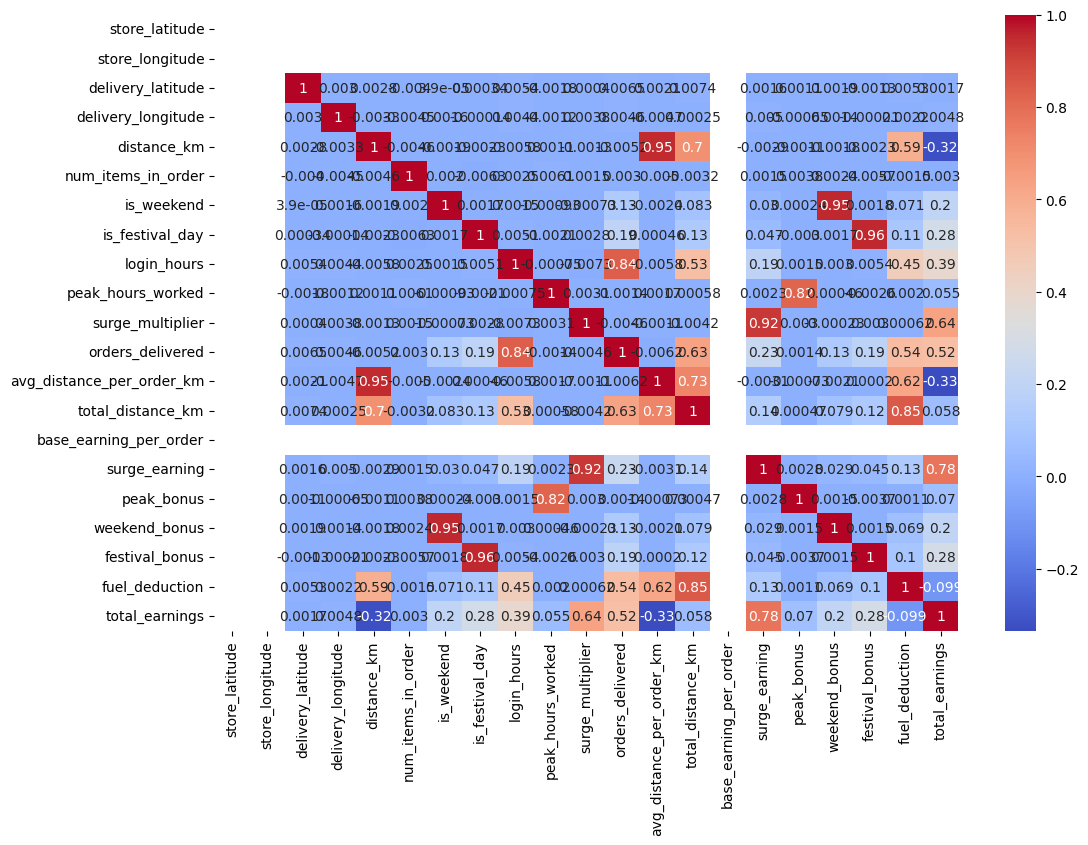

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

###  endode categorical columns

In [49]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    
    df[col] = label_encoder.fit_transform(df[col])

### split featues and targer

In [50]:
X = df.drop("total_earnings",axis=1)

y = df["total_earnings"]

### Train test split

In [51]:
X_train,X_test,y_train,y_test = train_test_split(
    
    X,
    y,
    test_size=0.20,
    random_state=42
    
)

In [52]:
### Feature scaling

In [53]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### save scaler

In [33]:
pickle.dump(
    
    scaler,
    
    open("scaler.pkl","wb")
    
)

### Build ANN

In [34]:
model = Sequential()

In [35]:
model.add(
    
    Dense(
        128,
        activation='relu',
        input_shape=(X_train.shape[1],)
    )
    
)

C:\Users\ashok\anaconda3\a1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.add(Dropout(0.3))

model.add(
    
    Dense(
        64,
        activation='relu'
    )
    
)

In [37]:
model.add(Dropout(0.3))

model.add(
    
    Dense(
        32,
        activation='relu'
    )
    
)

In [38]:
model.add(
    
    Dense(
        16,
        activation='relu'
    )
    
)

In [39]:
model.add(
    
    Dense(
        1
    )
    
)

### compile model

In [40]:
model.compile(
    
    optimizer='adam',
    
    loss='mse',
    
    metrics=['mae']
    
)

### Early stopping

In [ ]:
early_stop = EarlyStopping(
    
    monitor='val_loss',
    
    patience=10,
    
    restore_best_weights=True
    
)

### Train ANN

In [43]:
history = model.fit(
    
    X_train,
    
    y_train,
    
    validation_split=0.2,
    
    epochs=10,
    
    batch_size=32,
    
    callbacks=[early_stop]
    
)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1461.0964 - mae: 27.3147 - val_loss: 598.1058 - val_mae: 20.2171
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1125.2461 - mae: 23.2913 - val_loss: 1155.4731 - val_mae: 27.3155
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 895.2228 - mae: 20.3022 - val_loss: 2898.2678 - val_mae: 41.7097
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 616.3552 - mae: 16.6857 - val_loss: 6247.3335 - val_mae: 62.9134
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 466.3156 - mae: 14.3378 - val_loss: 6393.9263 - val_mae: 62.8391
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 387.6668 - mae: 12.9646 - val_loss: 6161.4668 - val_mae: 59.7430
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 329.5333 - mae: 11.8991 - val_loss: 6131.0459 - val_mae: 58.5493
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 292.3568 - mae: 11.2515 - val_loss: 5251.7017 - 

In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           3,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,165 (172.52 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,444 (115.02 KB)

### Save ANN model

In [45]:
model.save("zepto_ann_model.keras")

### prediction

In [46]:
predictions = model.predict(X_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


### EValuation

### MAE

In [47]:
mae = mean_absolute_error(
    
    y_test,
    
    predictions
    
)

print("MAE:",mae)

MAE: 20.144364207992556


### RMSE

In [55]:
rmse = np.sqrt(
    
    mean_squared_error(
        
        y_test,
        
        predictions
        
    )
)

print("RMSE:",rmse)

RMSE: 24.407045616821915


### R2 score 

In [56]:
r2 = r2_score(
    
    y_test,
    
    predictions
    
)

print("R2 Score:",r2)

R2 Score: 0.978906429658698


### Loss Graph

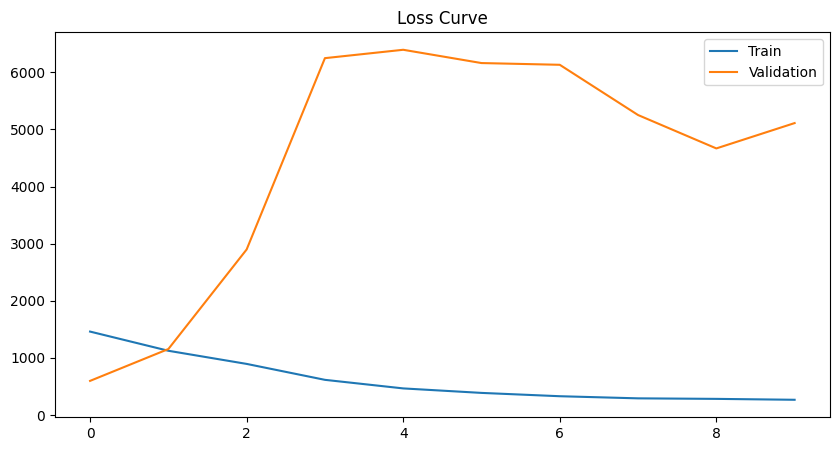

In [57]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.title("Loss Curve")

plt.show()

In [71]:
import pickle

with open(r"C:\Users\ashok\Downloads\scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [73]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/ann_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


In [70]:
import os
os.makedirs("models", exist_ok=True)

model.save("models/ann_model.keras")

import pickle
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [ ]:
model = load_model("zepto_ann_model.keras")

with open("scaler.pkl", "rb") as f: